# Quanto custa viver no Brasil?

Análise exploratória utilizando Python, Pandas e Matplotlib.

In [101]:
import pandas as pd
import matplotlib.pyplot as plt

df_renda = pd.read_csv("1-renda_domiciliar_per_capita_2025.csv", sep=";")
df_cesta =pd.read_csv("2-cesta_basica_capitais_dezembro_2025.csv", sep=";")

In [102]:
display(df_renda.head())
display(df_cesta.head())


,Unidade_Federacao,Rendimento_nominal_mensal_domiciliar_per_capita_R$
0,Brasil,2316
1,Rondônia,1991
2,Acre,1392
3,Amazonas,1484
4,Roraima,1878


,Capital,Valor_da_cesta_R$,Variacao_mensal_%_dezembro,Percentual_do_salario_minimo_liquido_%,Tempo_de_trabalho,Variacao_no_ano_%,Variacao_em_12_meses_%
0,São Paulo,"845,95","0,56","60,25",122h36m,"0,55","0,55"
1,Florianópolis,"801,29","0,08","57,07",116h08m,"-1,01","-1,01"
2,Rio de Janeiro,"792,06","1,03","56,41",114h47m,"1,57","1,57"
3,Cuiabá,"791,29","0,17","56,35",114h41m,NaN,NaN
4,Porto Alegre,"784,22","-0,7","55,85",113h40m,"0,06","0,06"


In [103]:
df_renda.info()
df_cesta.info()

<class 'pandas.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 2 columns):
 #   Column                                              Non-Null Count  Dtype
---  ------                                              --------------  -----
 0   Unidade_Federacao                                   28 non-null     str  
 1   Rendimento_nominal_mensal_domiciliar_per_capita_R$  28 non-null     int64
dtypes: int64(1), str(1)
memory usage: 580.0 bytes
<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 7 columns):
 #   Column                                  Non-Null Count  Dtype
---  ------                                  --------------  -----
 0   Capital                                 27 non-null     str  
 1   Valor_da_cesta_R$                       27 non-null     str  
 2   Variacao_mensal_%_dezembro              27 non-null     str  
 3   Percentual_do_salario_minimo_liquido_%  27 non-null     str  
 4   Tempo_de_trabalho                       27 n

In [104]:
df_renda.describe()

,Rendimento_nominal_mensal_domiciliar_per_capita_R$
count,28.000000
mean,2086.107143
std,716.731487
min,1219.000000
25%,1528.250000
50%,1934.500000
75%,2418.750000
max,4538.000000


In [105]:
df_cesta.describe()

,Capital,Valor_da_cesta_R$,Variacao_mensal_%_dezembro,Percentual_do_salario_minimo_liquido_%,Tempo_de_trabalho,Variacao_no_ano_%,Variacao_em_12_meses_%
count,27,27,27,27,27,17,17
unique,27,27,27,27,27,17,17
top,São Paulo,"845,95","0,56","60,25",122h36m,"0,55","0,55"
freq,1,1,1,1,1,1,1


In [106]:
# Corrigir o valor da cesta de str para float e substituir "," por "."
df_cesta["Valor_da_cesta_R$"] = df_cesta["Valor_da_cesta_R$"].str.replace(",",".").astype(float)
df_cesta["Variacao_mensal_%_dezembro"] = df_cesta["Variacao_mensal_%_dezembro"].str.replace(",",".").astype(float)
df_cesta["Percentual_do_salario_minimo_liquido_%"] = df_cesta["Percentual_do_salario_minimo_liquido_%"].str.replace(",",".").astype(float)
df_cesta["Variacao_no_ano_%"] = df_cesta["Variacao_no_ano_%"].str.replace(",",".").astype(float)
df_cesta["Variacao_em_12_meses_%"] = df_cesta["Variacao_em_12_meses_%"].str.replace(",",".").astype(float)
df_cesta.info()
df_cesta.describe()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 7 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Capital                                 27 non-null     str    
 1   Valor_da_cesta_R$                       27 non-null     float64
 2   Variacao_mensal_%_dezembro              27 non-null     float64
 3   Percentual_do_salario_minimo_liquido_%  27 non-null     float64
 4   Tempo_de_trabalho                       27 non-null     str    
 5   Variacao_no_ano_%                       17 non-null     float64
 6   Variacao_em_12_meses_%                  17 non-null     float64
dtypes: float64(5), str(2)
memory usage: 1.6 KB


,Valor_da_cesta_R$,Variacao_mensal_%_dezembro,Percentual_do_salario_minimo_liquido_%,Variacao_no_ano_%,Variacao_em_12_meses_%
count,27.000000,27.000000,27.000000,17.000000,17.000000
mean,680.901852,0.169630,48.491481,-0.306471,-0.306471
std,81.235695,1.411574,5.786274,2.095877,2.095877
min,539.490000,-3.600000,38.420000,-3.900000,-3.900000
25%,613.950000,-0.530000,43.720000,-1.520000,-1.520000
50%,666.570000,0.260000,47.470000,0.060000,0.060000
75%,732.550000,1.110000,52.170000,0.720000,0.720000
max,845.950000,3.190000,60.250000,4.040000,4.040000


In [107]:
# Montando um dicionário para relacionar os estados e capitais
capitais_estados ={
    "São Paulo": "São Paulo",
    "Florianópolis": "Santa Catarina",
    "Rio de Janeiro": "Rio de Janeiro",
    "Cuiabá": "Mato Grosso",
    "Porto Alegre": "Rio Grande do Sul",
    "Campo Grande": "Mato Grosso do Sul",
    "Curitiba": "Paraná",
    "Vitória": "Espírito Santo",
    "Goiânia": "Goiás",
    "Belo Horizonte": "Minas Gerais",
    "Brasília": "Distrito Federal",
    "Palmas": "Tocantins",
    "Fortaleza": "Ceará",
    "Belém": "Pará",
    "Boa Vista": "Roraima",
    "Macapá": "Amapá",
    "Teresina": "Piauí",
    "São Luís": "Maranhão",
    "Rio Branco": "Acre",
    "Manaus": "Amazonas",
    "Salvador": "Bahia",
    "João Pessoa": "Paraíba",
    "Natal": "Rio Grande do Norte",
    "Recife": "Pernambuco",
    "Porto Velho": "Rondônia",
    "Maceió": "Alagoas",
    "Aracaju": "Sergipe"}

df_cesta["Unidade_Federacao"] = df_cesta["Capital"].map(capitais_estados)
display(df_cesta.head())


,Capital,Valor_da_cesta_R$,Variacao_mensal_%_dezembro,Percentual_do_salario_minimo_liquido_%,Tempo_de_trabalho,Variacao_no_ano_%,Variacao_em_12_meses_%,Unidade_Federacao
0,São Paulo,845.95,0.56,60.25,122h36m,0.55,0.55,São Paulo
1,Florianópolis,801.29,0.08,57.07,116h08m,-1.01,-1.01,Santa Catarina
2,Rio de Janeiro,792.06,1.03,56.41,114h47m,1.57,1.57,Rio de Janeiro
3,Cuiabá,791.29,0.17,56.35,114h41m,NaN,NaN,Mato Grosso
4,Porto Alegre,784.22,-0.70,55.85,113h40m,0.06,0.06,Rio Grande do Sul


In [108]:
df_renda = df_renda[df_renda["Unidade_Federacao"] != "Brasil"]

df_final = df_cesta.merge(df_renda, on="Unidade_Federacao")

display(df_final.head())


,Capital,Valor_da_cesta_R$,Variacao_mensal_%_dezembro,Percentual_do_salario_minimo_liquido_%,Tempo_de_trabalho,Variacao_no_ano_%,Variacao_em_12_meses_%,Unidade_Federacao,Rendimento_nominal_mensal_domiciliar_per_capita_R$
0,São Paulo,845.95,0.56,60.25,122h36m,0.55,0.55,São Paulo,2956
1,Florianópolis,801.29,0.08,57.07,116h08m,-1.01,-1.01,Santa Catarina,2809
2,Rio de Janeiro,792.06,1.03,56.41,114h47m,1.57,1.57,Rio de Janeiro,2794
3,Cuiabá,791.29,0.17,56.35,114h41m,NaN,NaN,Mato Grosso,2335
4,Porto Alegre,784.22,-0.70,55.85,113h40m,0.06,0.06,Rio Grande do Sul,2839


In [109]:
# deixando a tabela mais simples e com as colunas que serão utilizadas por enquanto e renomeando coluna
df_final = df_final[["Unidade_Federacao","Capital","Valor_da_cesta_R$","Rendimento_nominal_mensal_domiciliar_per_capita_R$"]]
df_final = df_final.rename(columns={"Rendimento_nominal_mensal_domiciliar_per_capita_R$": "Renda_per_capita_R$"})
display(df_final)

,Unidade_Federacao,Capital,Valor_da_cesta_R$,Renda_per_capita_R$
0,São Paulo,São Paulo,845.95,2956
1,Santa Catarina,Florianópolis,801.29,2809
2,Rio de Janeiro,Rio de Janeiro,792.06,2794
3,Mato Grosso,Cuiabá,791.29,2335
4,Rio Grande do Sul,Porto Alegre,784.22,2839
5,Mato Grosso do Sul,Campo Grande,775.90,2454
6,Paraná,Curitiba,737.88,2762
7,Espírito Santo,Vitória,727.22,2249
8,Goiás,Goiânia,725.95,2407
9,Minas Gerais,Belo Horizonte,723.26,2353


In [110]:
#Criando um indicador 
#Quanto o valor da cesta básica representa em relação à renda domiciliar per capita?
df_final["Cesta_Sobre_Renda%"] = (df_final["Valor_da_cesta_R$"] / df_final["Renda_per_capita_R$"] *100)
df_final["Cesta_Sobre_Renda%"] = df_final["Cesta_Sobre_Renda%"].round(2)
display(df_final.head())

,Unidade_Federacao,Capital,Valor_da_cesta_R$,Renda_per_capita_R$,Cesta_Sobre_Renda%
0,São Paulo,São Paulo,845.95,2956,28.62
1,Santa Catarina,Florianópolis,801.29,2809,28.53
2,Rio de Janeiro,Rio de Janeiro,792.06,2794,28.35
3,Mato Grosso,Cuiabá,791.29,2335,33.89
4,Rio Grande do Sul,Porto Alegre,784.22,2839,27.62


In [111]:
df_final.sort_values(by="Cesta_Sobre_Renda%", ascending=True).head(10)
#Obtendo a media de porcentagem 
media_cesta_renda = df_final["Cesta_Sobre_Renda%"].mean()

round(media_cesta_renda, 2)




np.float64(35.18)

In [112]:
df_final[df_final["Cesta_Sobre_Renda%"]> 35.15]

acima_media= df_final["Cesta_Sobre_Renda%"] > 35.15
acima_media.sum()


np.int64(11)

In [113]:
df_final[df_final["Cesta_Sobre_Renda%"] < 35.15]

abaixo_media= df_final["Cesta_Sobre_Renda%"] < 35.15
abaixo_media.sum()

np.int64(16)

In [114]:
df_grafico = df_final.sort_values(by="Cesta_Sobre_Renda%", ascending=True)
display(df_grafico.head())

,Unidade_Federacao,Capital,Valor_da_cesta_R$,Renda_per_capita_R$,Cesta_Sobre_Renda%
10,Distrito Federal,Brasília,714.21,4538,15.74
6,Paraná,Curitiba,737.88,2762,26.72
4,Rio Grande do Sul,Porto Alegre,784.22,2839,27.62
2,Rio de Janeiro,Rio de Janeiro,792.06,2794,28.35
1,Santa Catarina,Florianópolis,801.29,2809,28.53


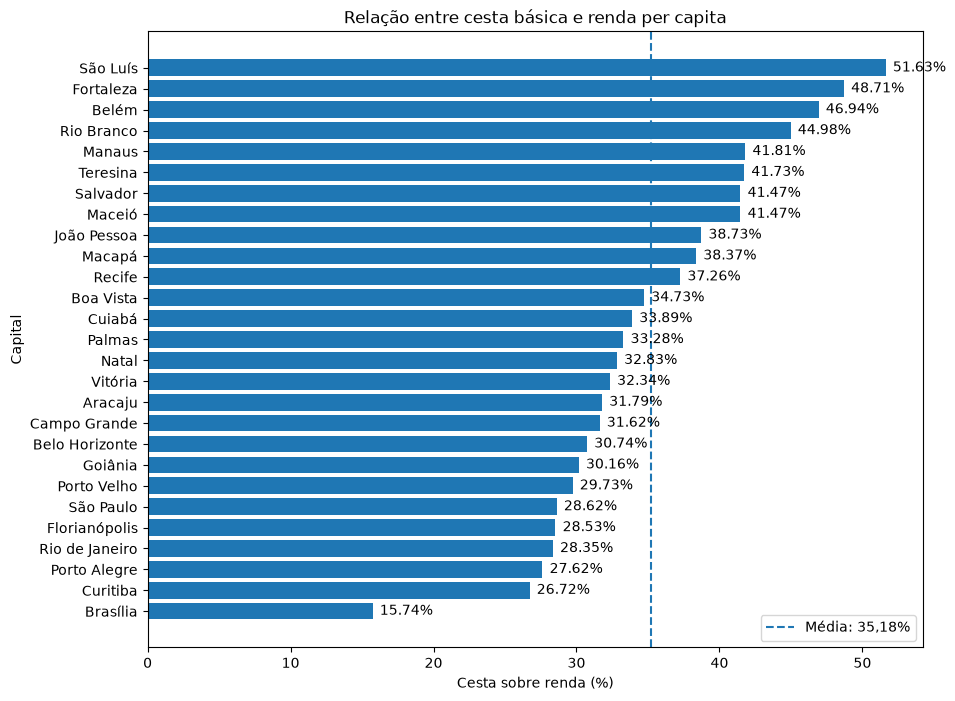

In [121]:
plt.figure(figsize=(10, 8))

plt.barh(
    df_grafico["Capital"],
    df_grafico["Cesta_Sobre_Renda%"]
)
for i, valor in enumerate(df_grafico["Cesta_Sobre_Renda%"]):
    plt.text(
        valor + 0.5,
        i,
        f"{valor:.2f}%",
        va="center"
    )

plt.xlabel("Cesta sobre renda (%)")
plt.ylabel("Capital")
plt.title("Relação entre cesta básica e renda per capita")

plt.axvline(
    35.18,
    linestyle="--",
    label="Média: 35,18%"
)

plt.legend()

plt.show()